<a href="https://colab.research.google.com/github/sthefany-vg/Decision-Aid/blob/main/LAB1_MVs_Imputation_kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAPPC – LAB 1
## kNN Missing Value Imputation

In this notebook you will:

1. Load a prepared dataset  
2. Explore missing values  
3. Apply k-Nearest Neighbors (kNN) imputation  
4. Compare missing values before and after imputation  
5. Save the imputed dataset

We assume:
- The dataset is already cleaned (columns/rows filtered)
- Outcome has 3 classes (0,1,2)

## 0) Setup


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from scipy.stats import mode

## 1) Load Dataset


In [ ]:
# === TODO: set your file path and sheet name ===
# Volvemos a usar nuestro archivo maestro limpio, partiendo desde la versión base con vacíos
file_path = 'Dataset_DAPPC_2026_Cleaned.xlsx'
sheet_name = 'Dataset_v1'

# Cargamos el DataFrame
df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Initial shape:", df.shape)
df.head()


Initial shape: (3893, 75)


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,gender,age,weight,charlson_comorbidity_index,...,std_mean_airway_pressure,first_plateau_pressure,std_plateau_pressure,vent_duration_hours,outcome,comorb_cardiac_cardiovascular,comorb_respiratory_pulmonary,comorb_metabolic_endocrine_renal,comorb_neurological_neuromuscular_psychiatric,comorb_systemic_immune_oncologic
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,1,66,113.3,3,...,1.923269,19.0,1.909727,96.0,2,0,0,1,0,0
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,1,53,106.7,5,...,6.393488,10.0,8.337289,230.0,1,0,1,1,0,0
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,0,66,46.1,6,...,2.184796,17.0,1.224745,34.0,1,0,0,1,0,0
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,1,49,106.0,1,...,4.233572,11.0,4.877563,399.0,2,1,0,1,1,0
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,0,77,49.3,7,...,1.405487,17.0,3.239768,155.0,2,1,0,1,0,1


## 2) Column Index Table


In [ ]:
display(pd.DataFrame({
    "index": np.arange(df.shape[1]),
    "column_name": df.columns,
    "dtype": df.dtypes
}))


,index,column_name,dtype
subject_id,0,subject_id,int64
hadm_id,1,hadm_id,int64
stay_id,2,stay_id,int64
ICU,3,ICU,int64
ICU_intime,4,ICU_intime,object
...,...,...,...
comorb_cardiac_cardiovascular,70,comorb_cardiac_cardiovascular,int64
comorb_respiratory_pulmonary,71,comorb_respiratory_pulmonary,int64
comorb_metabolic_endocrine_renal,72,comorb_metabolic_endocrine_renal,int64
comorb_neurological_neuromuscular_psychiatric,73,comorb_neurological_neuromuscular_psychiatric,int64


## 3) Explore Missing Values

In [ ]:
# Total missing values (global)
print("Total missing values:", df.isna().sum().sum())

# Missing per column: count + percentage
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2)
})

# Mostra solo colonne con almeno un missing
missing_table = missing_table[missing_table["missing_count"] > 0] \
                    .sort_values("missing_%", ascending=False)

display(missing_table)


Total missing values: 906


,missing_count,missing_%
weight,177,4.55
std_plateau_pressure,140,3.60
first_plateau_pressure,137,3.52
first_temperature,58,1.49
std_PTT,57,1.46
first_PTT,57,1.46
std_PT,54,1.39
std_temperature,53,1.36
first_PT,53,1.36
std_PEEP,34,0.87


## 4) Apply kNN Imputation

## kNN Imputation

kNN imputation works as follows:
1. Define the TRS (subjects without any missing value)
2. For each subject with at least one MV:

   a) Compute the distance between the subejct and the TRS elements (only on the featuers without MVs, L1 distance)

   b) Identify the first k-neighbors

   c) Impute the MVs according to the type of feature (mean value for continous variables, median value for integer variables, majority voting for categorical variables)   

We will:
- Only clinically meaningful numeric variables should be imputed -> Use only the input features (not the class or the IDs)
- Use k = 50 neighbors

In [ ]:
# ============================================================
# Define variable groups: you should obtain the names of the features divided by type
# ============================================================

# Variables continuas: Parámetros de laboratorio y signos vitales medidos con decimales
continuous_vars = [
    "weight", "first_pCO2", "std_pCO2", "first_pH", "std_pH", "first_pO2", "std_pO2",
    "first_PT", "std_PT", "first_PTT", "std_PTT", "std_chloride", "first_creatinine",
    "std_creatinine", "first_glycemia", "std_glycemia", "first_hemoglobin", "std_hemoglobin",
    "first_phosphate", "std_phosphate", "std_platelets", "first_potassium", "std_potassium",
    "std_sodium", "first_wbc", "std_wbc", "first_diastolic_blood_pressure", "std_diastolic_blood_pressure",
    "first_mean_blood_pressure", "std_mean_blood_pressure", "first_systolic_blood_pressure",
    "std_systolic_blood_pressure", "first_heart_rate", "std_heart_rate", "first_respiratory_rate",
    "std_respiratory_rate", "first_temperature", "std_temperature", "first_PEEP", "std_PEEP",
    "first_PIP", "std_PIP", "first_mean_airway_pressure", "std_mean_airway_pressure",
    "first_plateau_pressure", "std_plateau_pressure", "vent_duration_hours", "sedative_duration_hours"
]

# Variables enteras (Integer): Puntuaciones de escalas médicas y recuentos
integer_vars = [
    "age", "charlson_comorbidity_index", "gcs", "sofa", "sirs", "sapsii",
    "comorb_total", "first_chloride", "first_platelets", "first_sodium"
]

# Variables categóricas: Flags binarios de tratamientos y las 5 comorbilidades agrupadas
categorical_vars = [
    "gender", "vasopressors", "sedatives", "neuromuscular_blockers", "steroids", "opioids",
    "comorb_cardiac_cardiovascular", "comorb_respiratory_pulmonary",
    "comorb_metabolic_endocrine_renal", "comorb_neurological_neuromuscular_psychiatric",
    "comorb_systemic_immune_oncologic"
]

# Unión ordenada de todas las variables clínicas que procesará el kNN
input_features = continuous_vars + integer_vars + categorical_vars

# Number of neighbors
# Definimos los 50 vecinos más cercanos solicitados por la guía
k = 50

In [ ]:
# ============================================================
# Split subjects into:
#    - TRS: subjects without missing values
#    - subjects with missing values
# ============================================================

# --- CONTROL DE SEGURIDAD ---
# Nos aseguramos de que 'comorb_total' exista sumando las 5 categorías de comorbilidades
if 'comorb_total' not in df.columns:
    cat_cols = [col for col in df.columns if col.startswith('comorb_')]
    df['comorb_total'] = df[cat_cols].sum(axis=1)

# Extraemos la matriz con únicamente las variables clínicas que definimos
X = df[input_features].copy()

# X_trs: Filtramos para obtener los sujetos sin ningún valor faltante
X_trs = X.dropna()

# X_missing: Filtramos para aislar los sujetos que tienen al menos un dato nulo (NaN)
X_missing = X[X.isna().any(axis=1)]

# Check how many subjects are in each set
print("TRS subjects:", X_trs.shape[0])
print("Subjects with MVs:", X_missing.shape[0])

# ============================================================
# 3. Normalize TRS subjects
# ============================================================
scaler = MinMaxScaler()

# fit_transform calcula mínimos y máximos sobre el TRS y escala todo entre 0 y 1
X_trs_scaled = pd.DataFrame(
    scaler.fit_transform(X_trs),
    columns=X_trs.columns,
    index=X_trs.index
)

TRS subjects: 3378
Subjects with MVs: 515


In [ ]:
# ============================================================
# Impute missing values subject by subject
# ============================================================

X_imputed = X.copy()

# Loop over subjects with missing values
for subject_idx in X_missing.index:

    # Current subject (extraemos el registro original del paciente actual)
    subject = X_missing.loc[subject_idx]

    # Normalize subject using the scaler fitted on TRS
    subject_scaled = pd.DataFrame(
        scaler.transform(subject.to_frame().T),
        columns=X_trs.columns,
        index=[subject_idx]
    )

    # Keep only observed (non NAN) variables (las variables que SÍ están presentes)
    observed_vars = subject.dropna().index.tolist()

    # Compare the subject only on observed variables
    trs_observed = X_trs_scaled[observed_vars]
    subject_observed = subject_scaled.loc[subject_idx, observed_vars]

    # Compute L1 distances with respect to all TRS subjects (suma de diferencias absolutas)
    distances = np.sum(np.abs(trs_observed - subject_observed), axis=1)

    # Select the k nearest neighbors
    # Ordenamos de menor a mayor distancia y tomamos los primeros 'k' (50 vecinos)
    nearest_subjects = distances.sort_values(ascending=True).head(k)
    # Extraemos los datos reales (no normalizados) correspondientes a esos 50 vecinos del TRS
    neighbors = X_trs.loc[nearest_subjects.index]

    # Identify missing variables for the current subject (las variables que están vacías)
    missing_vars = subject[subject.isna()].index.tolist()

    # Impute MVs according to the type of each feature (3 cases)
    for var in missing_vars:
        if var in continuous_vars:
            # Caso a: Promedio (mean) para variables continuas
            X_imputed.loc[subject_idx, var] = neighbors[var].mean()

        elif var in integer_vars:
            # Caso b: Mediana (median) para variables enteras
            X_imputed.loc[subject_idx, var] = neighbors[var].median()

        elif var in categorical_vars:
            # Caso c: Voto de la mayoría / Moda (majority voting) usando scipy
            # mode() devuelve un objeto, agregamos [0] para extraer el valor numérico
            X_imputed.loc[subject_idx, var] = mode(neighbors[var], keepdims=True).mode[0]

# ============================================================
# 5. Rebuild final dataset
# ============================================================
df_final = df.copy()
df_final[input_features] = X_imputed[input_features]

# Validación final: Nos aseguramos de que el contador global de nulos llegue a 0
print("Valores faltantes restantes en df_final (kNN global):", df_final[input_features].isna().sum().sum())

Valores faltantes restantes en df_final (kNN global): 0


## 5) Final saving

In [ ]:
# 5) Final saving
# Save the imputed dataset (kNN on all patients) into a new Excel sheet (Not a new file!)

file_path = 'Dataset_DAPPC_2026_Cleaned.xlsx'
new_sheet_name = "Dataset_step_3a"

# Abrimos el archivo en modo append ('a') para registrar los datos del kNN global
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_final.to_excel(writer, sheet_name=new_sheet_name, index=False)

print(f"¡Éxito! El dataset imputado mediante kNN global se ha guardado correctamente.")
print(f"Archivo: '{file_path}' | Hoja: '{new_sheet_name}'")


¡Éxito! El dataset imputado mediante kNN global se ha guardado correctamente.
Archivo: 'Dataset_DAPPC_2026_Cleaned.xlsx' | Hoja: 'Dataset_step_3a'


---
## kNN Imputation by Outcome Class

In this section we perform kNN imputation **separately for each outcome class (0 / 1 / 2)**.

Why?
- Patients from different outcome classes may have different clinical distributions.
- Imputing within class preserves intra-class similarity.


In [ ]:
# STEP 3b — kNN imputation separately for each outcome class

# Idea:
# - split patients by outcome class
# - apply the SAME normalization + kNN imputation inside each class subset
# - concatenate all imputed subsets
...

In [ ]:
# STEP 3b — kNN imputation separately for each outcome class

# Lista para almacenar los bloques de datos imputados por clase
imputed_subsets_knn = []

# Iteramos de manera independiente sobre cada clase única de outcome (0, 1, 2)
for outcome_class in sorted(df['outcome'].unique()):
    print(f"\n>>> PROCESANDO PACIENTES POR kNN EN OUTCOME: {outcome_class} <<<")

    # 1. Filtramos el DataFrame original para aislar la clase actual
    df_class = df[df['outcome'] == outcome_class].copy()

    # 2. Extraemos las características clínicas requeridas
    X_class = df_class[input_features].copy()

    # Control preventivo de la variable de comorbilidades totales
    if 'comorb_total' not in X_class.columns:
        cat_cols = [col for col in X_class.columns if col.startswith('comorb_')]
        X_class['comorb_total'] = X_class[cat_cols].sum(axis=1)

    # 3. Separamos en TRS (completos) y registros con MVs específicos de esta clase
    X_trs_class = X_class.dropna().copy()
    X_missing_class = X_class[X_class.isna().any(axis=1)].copy()

    print(f"   [Clase {outcome_class}] Sujetos TRS: {X_trs_class.shape[0]} | Sujetos con MVs: {X_missing_class.shape[0]}")

    # Si la clase no presenta registros con valores faltantes, guardamos el bloque y saltamos
    if X_missing_class.empty:
        imputed_subsets_knn.append(df_class)
        continue

    # 4. Normalizamos el TRS usando un MinMaxScaler ajustado solo a esta clase
    scaler_class = MinMaxScaler()
    X_trs_scaled_class = pd.DataFrame(
        scaler_class.fit_transform(X_trs_class),
        columns=X_trs_class.columns,
        index=X_trs_class.index
    )

    # 5. Inicializamos la copia de la matriz donde se asentarán las imputaciones
    X_imputed_class = X_class.copy()

    # Ajuste adaptativo de 'k' por seguridad: el número de vecinos no puede superar el tamaño del TRS de la clase
    k_class = min(k, X_trs_class.shape[0])
    if k_class < k:
        print(f"   ⚠️ Nota: El TRS de la clase {outcome_class} es pequeño. Ajustando k a {k_class} vecinos.")

    # 6. Bucle de imputación paciente por paciente dentro de la clase actual
    for subject_idx in X_missing_class.index:
        subject = X_missing_class.loc[subject_idx]

        # Escalamiento del paciente actual con los parámetros de su clase
        subject_scaled = pd.DataFrame(
            scaler_class.transform(subject.to_frame().T),
            columns=X_trs_class.columns,
            index=[subject_idx]
        )

        # Identificamos variables medidas (observadas) y faltantes (nulas)
        observed_vars = subject.dropna().index.tolist()
        missing_vars = subject[subject.isna()].index.tolist()

        # Filtramos matrices para comparar solo las columnas que el paciente sí tiene registradas
        trs_observed = X_trs_scaled_class[observed_vars]
        subject_observed = subject_scaled.loc[subject_idx, observed_vars]

        # Medimos distancias L1 (Manhattan) exclusivamente contra el TRS de su propia clase
        distances = np.sum(np.abs(trs_observed - subject_observed), axis=1)

        # Seleccionamos las posiciones e índices de los vecinos más cercanos en el grupo
        nearest_subjects = distances.sort_values(ascending=True).head(k_class)
        neighbors = X_trs_class.loc[nearest_subjects.index]

        # Imputamos los vacíos aplicando los 3 criterios de la guía clínica
        for var in missing_vars:
            if var in continuous_vars:
                # Media pura para variables continuas
                X_imputed_class.loc[subject_idx, var] = neighbors[var].mean()
            elif var in integer_vars:
                # Mediana pura para variables enteras
                X_imputed_class.loc[subject_idx, var] = neighbors[var].median()
            elif var in categorical_vars:
                # Voto mayoritario (Moda) para variables categóricas
                X_imputed_class.loc[subject_idx, var] = mode(neighbors[var], keepdims=True).mode[0]

    # 7. Sincronizamos las variables imputadas con el DataFrame base del subset
    df_class_final = df_class.copy()
    df_class_final[input_features] = X_imputed_class[input_features]

    # Almacenamos el bloque procesado
    imputed_subsets_knn.append(df_class_final)

# ============================================================
# CONCATENACIÓN Y REORGANIZACIÓN FINAL
# ============================================================
# Consolidamos los subsets de las 3 clases y restauramos el orden de índices original
df_final_knn_by_class = pd.concat(imputed_subsets_knn).sort_index()

print("\n>>> IMPUTACIÓN kNN POR CLASES COMPLETADA <<<")
print("Dimensiones finales del dataset:", df_final_knn_by_class.shape)
print("Valores nulos clínicos remanentes:", df_final_knn_by_class[input_features].isna().sum().sum())


>>> PROCESANDO PACIENTES POR kNN EN OUTCOME: 0 <<<
   [Clase 0] Sujetos TRS: 700 | Sujetos con MVs: 76

>>> PROCESANDO PACIENTES POR kNN EN OUTCOME: 1 <<<
   [Clase 1] Sujetos TRS: 1654 | Sujetos con MVs: 294

>>> PROCESANDO PACIENTES POR kNN EN OUTCOME: 2 <<<
   [Clase 2] Sujetos TRS: 1024 | Sujetos con MVs: 145

>>> IMPUTACIÓN kNN POR CLASES COMPLETADA <<<
Dimensiones finales del dataset: (3893, 76)
Valores nulos clínicos remanentes: 0


## Final saving

In [ ]:
# Final saving
# Save the imputed dataset (kNN by class) into a new Excel sheet (Not a new file!)

file_path = 'Dataset_DAPPC_2026_Cleaned.xlsx'
new_sheet_name = "Dataset_step_3b_final"

# Abrimos el archivo en modo append ('a') para registrar los datos del kNN por clases de outcome
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_final_knn_by_class.to_excel(writer, sheet_name=new_sheet_name, index=False)

print(f"¡Excelente trabajo! El dataset imputado mediante kNN por clases se guardó correctamente.")
print(f"Archivo: '{file_path}' | Hoja: '{new_sheet_name}'")

¡Excelente trabajo! El dataset imputado mediante kNN por clases se guardó correctamente.
Archivo: 'Dataset_DAPPC_2026_Cleaned.xlsx' | Hoja: 'Dataset_step_3b_final'


#PARTE 4: Representación Gráfica de Variables

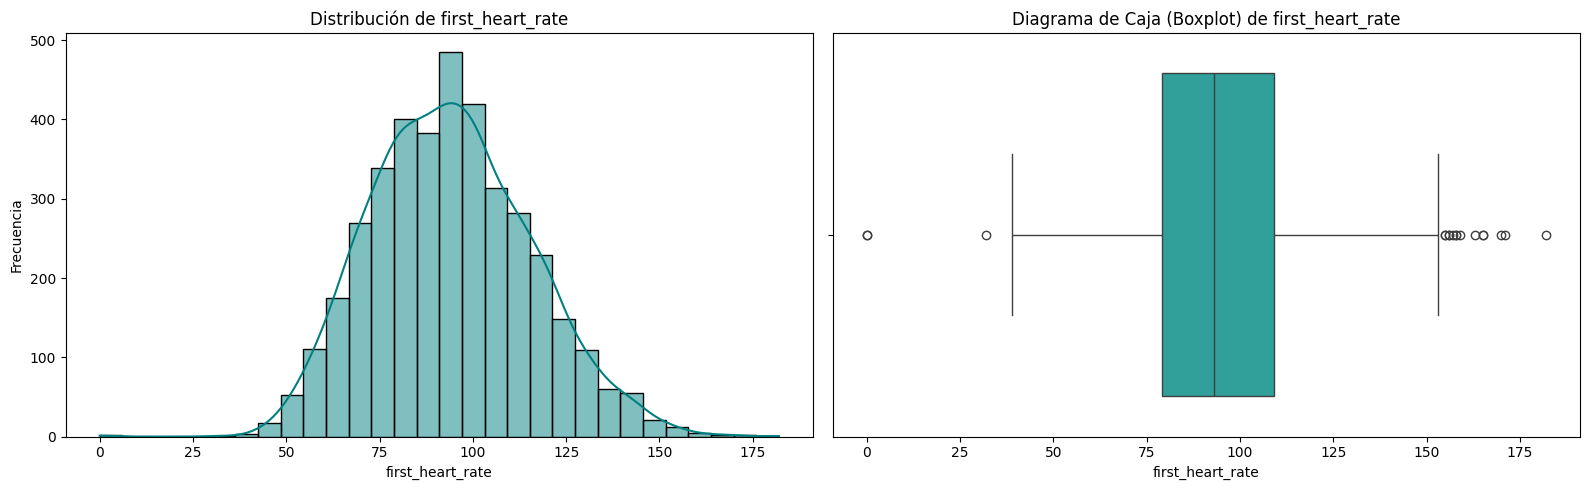

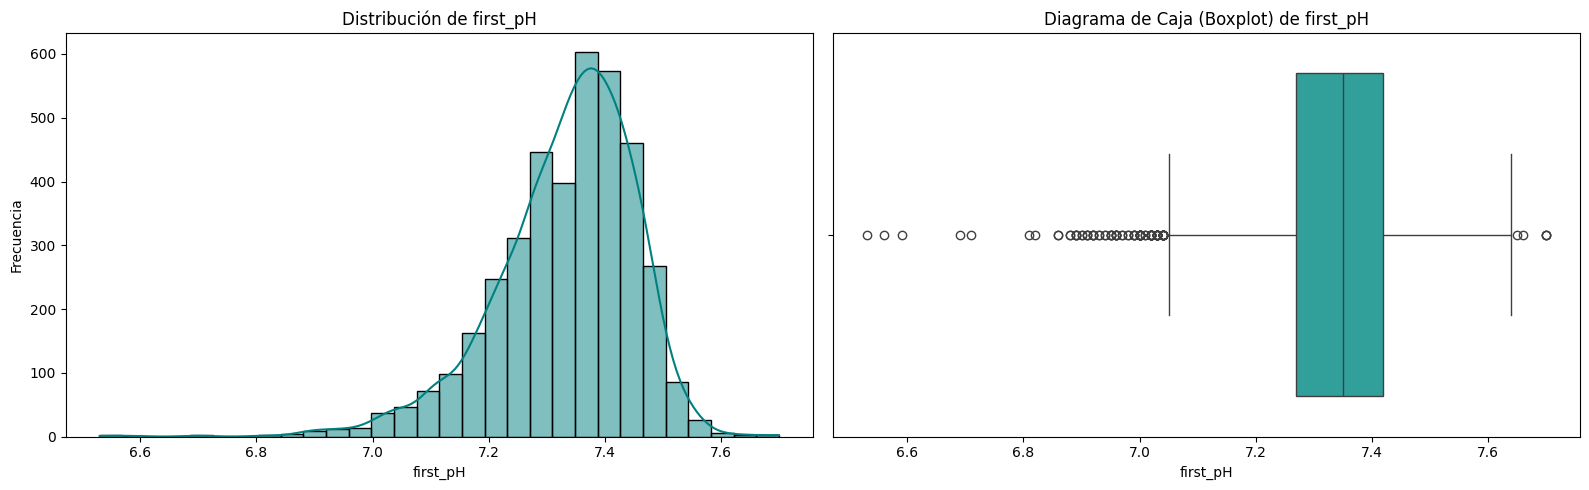

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargamos el dataset imputado por clases para el análisis
df_eda = pd.read_excel('Dataset_DAPPC_2026_Cleaned.xlsx', sheet_name='Dataset_step_3b')

def visualizar_variable(dataframe, columna):
    """
    Genera un histograma con curva KDE y un Boxplot en paralelo
    para analizar la distribución y detectar outliers visualmente.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Gráfico 1: Histograma + Densidad (KDE)
    sns.histplot(data=dataframe, x=columna, kde=True, ax=axes[0], color='teal', bins=30)
    axes[0].set_title(f"Distribución de {columna}")
    axes[0].set_ylabel("Frecuencia")

    # Gráfico 2: Boxplot (Muestra la mediana, cuartiles y puntos outliers)
    sns.boxplot(data=dataframe, x=columna, ax=axes[1], color='lightseagreen')
    axes[1].set_title(f"Diagrama de Caja (Boxplot) de {columna}")

    plt.tight_layout()
    plt.show()

# --- EJEMPLO DE USO ---
# Vamos a visualizar un par de variables fisiológicas críticas para probar el motor gráfico
visualizar_variable(df_eda, 'first_heart_rate')
visualizar_variable(df_eda, 'first_pH')

# 5) Detección de Outliers (Método IQR)

In [ ]:
# Unimos continuas y enteras para el análisis de límites numéricos
variables_numericas = continuous_vars + integer_vars

outlier_summary = []

# Analizamos variable por variable
for col in variables_numericas:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Contamos cuántos registros rompen las barreras médicas matemáticas
    outliers_inf = df_eda[df_eda[col] < limite_inferior].shape[0]
    outliers_sup = df_eda[df_eda[col] > limite_superior].shape[0]
    total_outliers = outliers_inf + outliers_sup
    porcentaje = (total_outliers / df_eda.shape[0]) * 100

    outlier_summary.append({
        "Variable": col,
        "Límite Inf": round(limite_inferior, 2),
        "Límite Sup": round(limite_superior, 2),
        "Total Outliers": total_outliers,
        "Porcentaje (%)": round(porcentaje, 2)
    })

# Convertimos el reporte a DataFrame y filtramos para ver cuáles tienen más ruido
df_outliers = pd.DataFrame(outlier_summary).sort_values(by="Total Outliers", ascending=False)

print(f"--- REPORTE GLOBAL DE OUTLIERS (Total de pacientes: {df_eda.shape[0]}) ---")
df_outliers.head(15) # Mostramos las 15 variables con mayor cantidad de valores atípicos

--- REPORTE GLOBAL DE OUTLIERS (Total de pacientes: 3893) ---


,Variable,Límite Inf,Límite Sup,Total Outliers,Porcentaje (%)
50,gcs,15.00,15.00,535,13.74
8,std_PT,-2.96,6.57,423,10.87
12,first_creatinine,-0.70,3.30,398,10.22
7,first_PT,4.85,25.25,395,10.15
38,first_PEEP,0.50,12.50,386,9.92
9,first_PTT,10.80,54.00,357,9.17
13,std_creatinine,-0.57,1.24,354,9.09
47,sedative_duration_hours,-152.50,315.50,282,7.24
36,first_temperature,35.19,38.53,267,6.86
46,vent_duration_hours,-121.00,311.00,267,6.86
